# Q2 : RANSAC for Line & Circle (Robust Fitting)

**Objective**  
Separate a line and a circle from a noisy 2-D point set using **RANSAC**, then refit each model on its inliers.

**Inputs**  
- Synthetic point set: 50 near a circle, 50 near a line (Gaussian noise)

**Key Parameters**  
- Line: distance threshold, min consensus, iterations  
- Circle: radial threshold, min consensus, iterations

**Method**  
1) RANSAC-line (unit-normal form \(ax+by=d\)); remove its inliers.  
2) RANSAC-circle (algebraic fit); refine on inliers.  
3) Report models, inlier counts, and visualize best samples + fits.

**Outputs**  
- Best line \((a,b,d)\), best circle \((x_c,y_c,r)\)  
- Inlier counts, sampled indices  
- Plot: all points, inliers, best fits, and GT overlays


In [60]:
from scipy.optimize import minimize
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
DATA = Path("../data")
RESULTS = Path("../results/q2")
RESULTS.mkdir(parents=True, exist_ok=True)

# Generate synthetic dataset
np.random.seed(0)
N = 100
half_n = N // 2

# Circle points
r_gt = 10
x0_gt, y0_gt = 2, 3  # Ground truth center
s_circ = r_gt / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s_circ * np.random.randn(half_n)
x_circ = x0_gt + (r_gt + n) * np.cos(t)
y_circ = y0_gt + (r_gt + n) * np.sin(t)
X_circ = np.hstack((x_circ.reshape(-1, 1), y_circ.reshape(-1, 1)))

# Line points
s_line = 1.0
m_gt, b_gt = -1, 2
x_line = np.linspace(-12, 12, half_n)
y_line = m_gt * x_line + b_gt + s_line * np.random.randn(half_n)
X_line = np.hstack((x_line.reshape(-1, 1), y_line.reshape(-1, 1)))

# Full point set
X = np.vstack((X_circ, X_line))

# Save ground truth for reference
np.savez(RESULTS / "ground_truth.npz",
         circle_center=[x0_gt, y0_gt],
         circle_radius=r_gt,
         line_slope=m_gt,
         line_intercept=b_gt,
         X=X,
         X_line=X_line,
         X_circ=X_circ)

In [94]:
def line_distance(params, points):
    """Compute perpendicular distance from points to line ax + by + d = 0."""
    a, b, d = params
    norm = np.sqrt(a**2 + b**2)
    return np.abs(a * points[:, 0] + b * points[:, 1] + d) / norm


def fit_line_from_two_points(p1, p2):
    """Compute normalized line parameters [a, b, d] from two points."""
    a = p2[1] - p1[1]
    b = p1[0] - p2[0]
    d = -(a * p1[0] + b * p1[1])
    norm = np.sqrt(a**2 + b**2)
    if norm == 0:
        return None
    return np.array([a, b, d]) / norm


def circle_distance(params, points):
    """Compute radial distance from points to circle (x0, y0, r)."""
    x0, y0, r = params
    return np.abs(np.sqrt((points[:, 0] - x0)**2 + (points[:, 1] - y0)**2) - r)


def fit_circle_from_three_points(p1, p2, p3):
    """Fit circle from 3 points using linear algebra. Returns (x0, y0, r) or None."""
    A = np.array([
        [p1[0], p1[1], 1],
        [p2[0], p2[1], 1],
        [p3[0], p3[1], 1]
    ])
    B = -np.array([
        p1[0]**2 + p1[1]**2,
        p2[0]**2 + p2[1]**2,
        p3[0]**2 + p3[1]**2
    ])
    try:
        C = np.linalg.solve(A, B)
        x0 = -0.5 * C[0]
        y0 = -0.5 * C[1]
        r_sq = x0**2 + y0**2 - C[2]
        if r_sq <= 0:
            return None
        r = np.sqrt(r_sq)
        return (x0, y0, r)
    except np.linalg.LinAlgError:
        return None


def ransac_line(points, num_iterations=1000, threshold=0.61, min_inliers=34):
    """RANSAC line fitting with unit normal constraint."""
    best_inliers = []
    best_params = None
    N = len(points)

    for _ in range(num_iterations):
        idx = np.random.choice(N, 2, replace=False)
        p1, p2 = points[idx]
        params = fit_line_from_two_points(p1, p2)
        if params is None:
            continue

        distances = line_distance(params, points)
        inliers = points[distances < threshold]

        if len(inliers) >= min_inliers and len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = params

    return best_params, best_inliers


def ransac_circle(points, num_iterations=1000, threshold=1.49, min_inliers=44):
    """RANSAC circle fitting."""
    best_inliers = []
    best_params = None
    N = len(points)

    for _ in range(num_iterations):
        idx = np.random.choice(N, 3, replace=False)
        p1, p2, p3 = points[idx]
        params = fit_circle_from_three_points(p1, p2, p3)
        if params is None:
            continue

        distances = circle_distance(params, points)
        inliers = points[distances < threshold]

        if len(inliers) >= min_inliers and len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = params

    return best_params, best_inliers

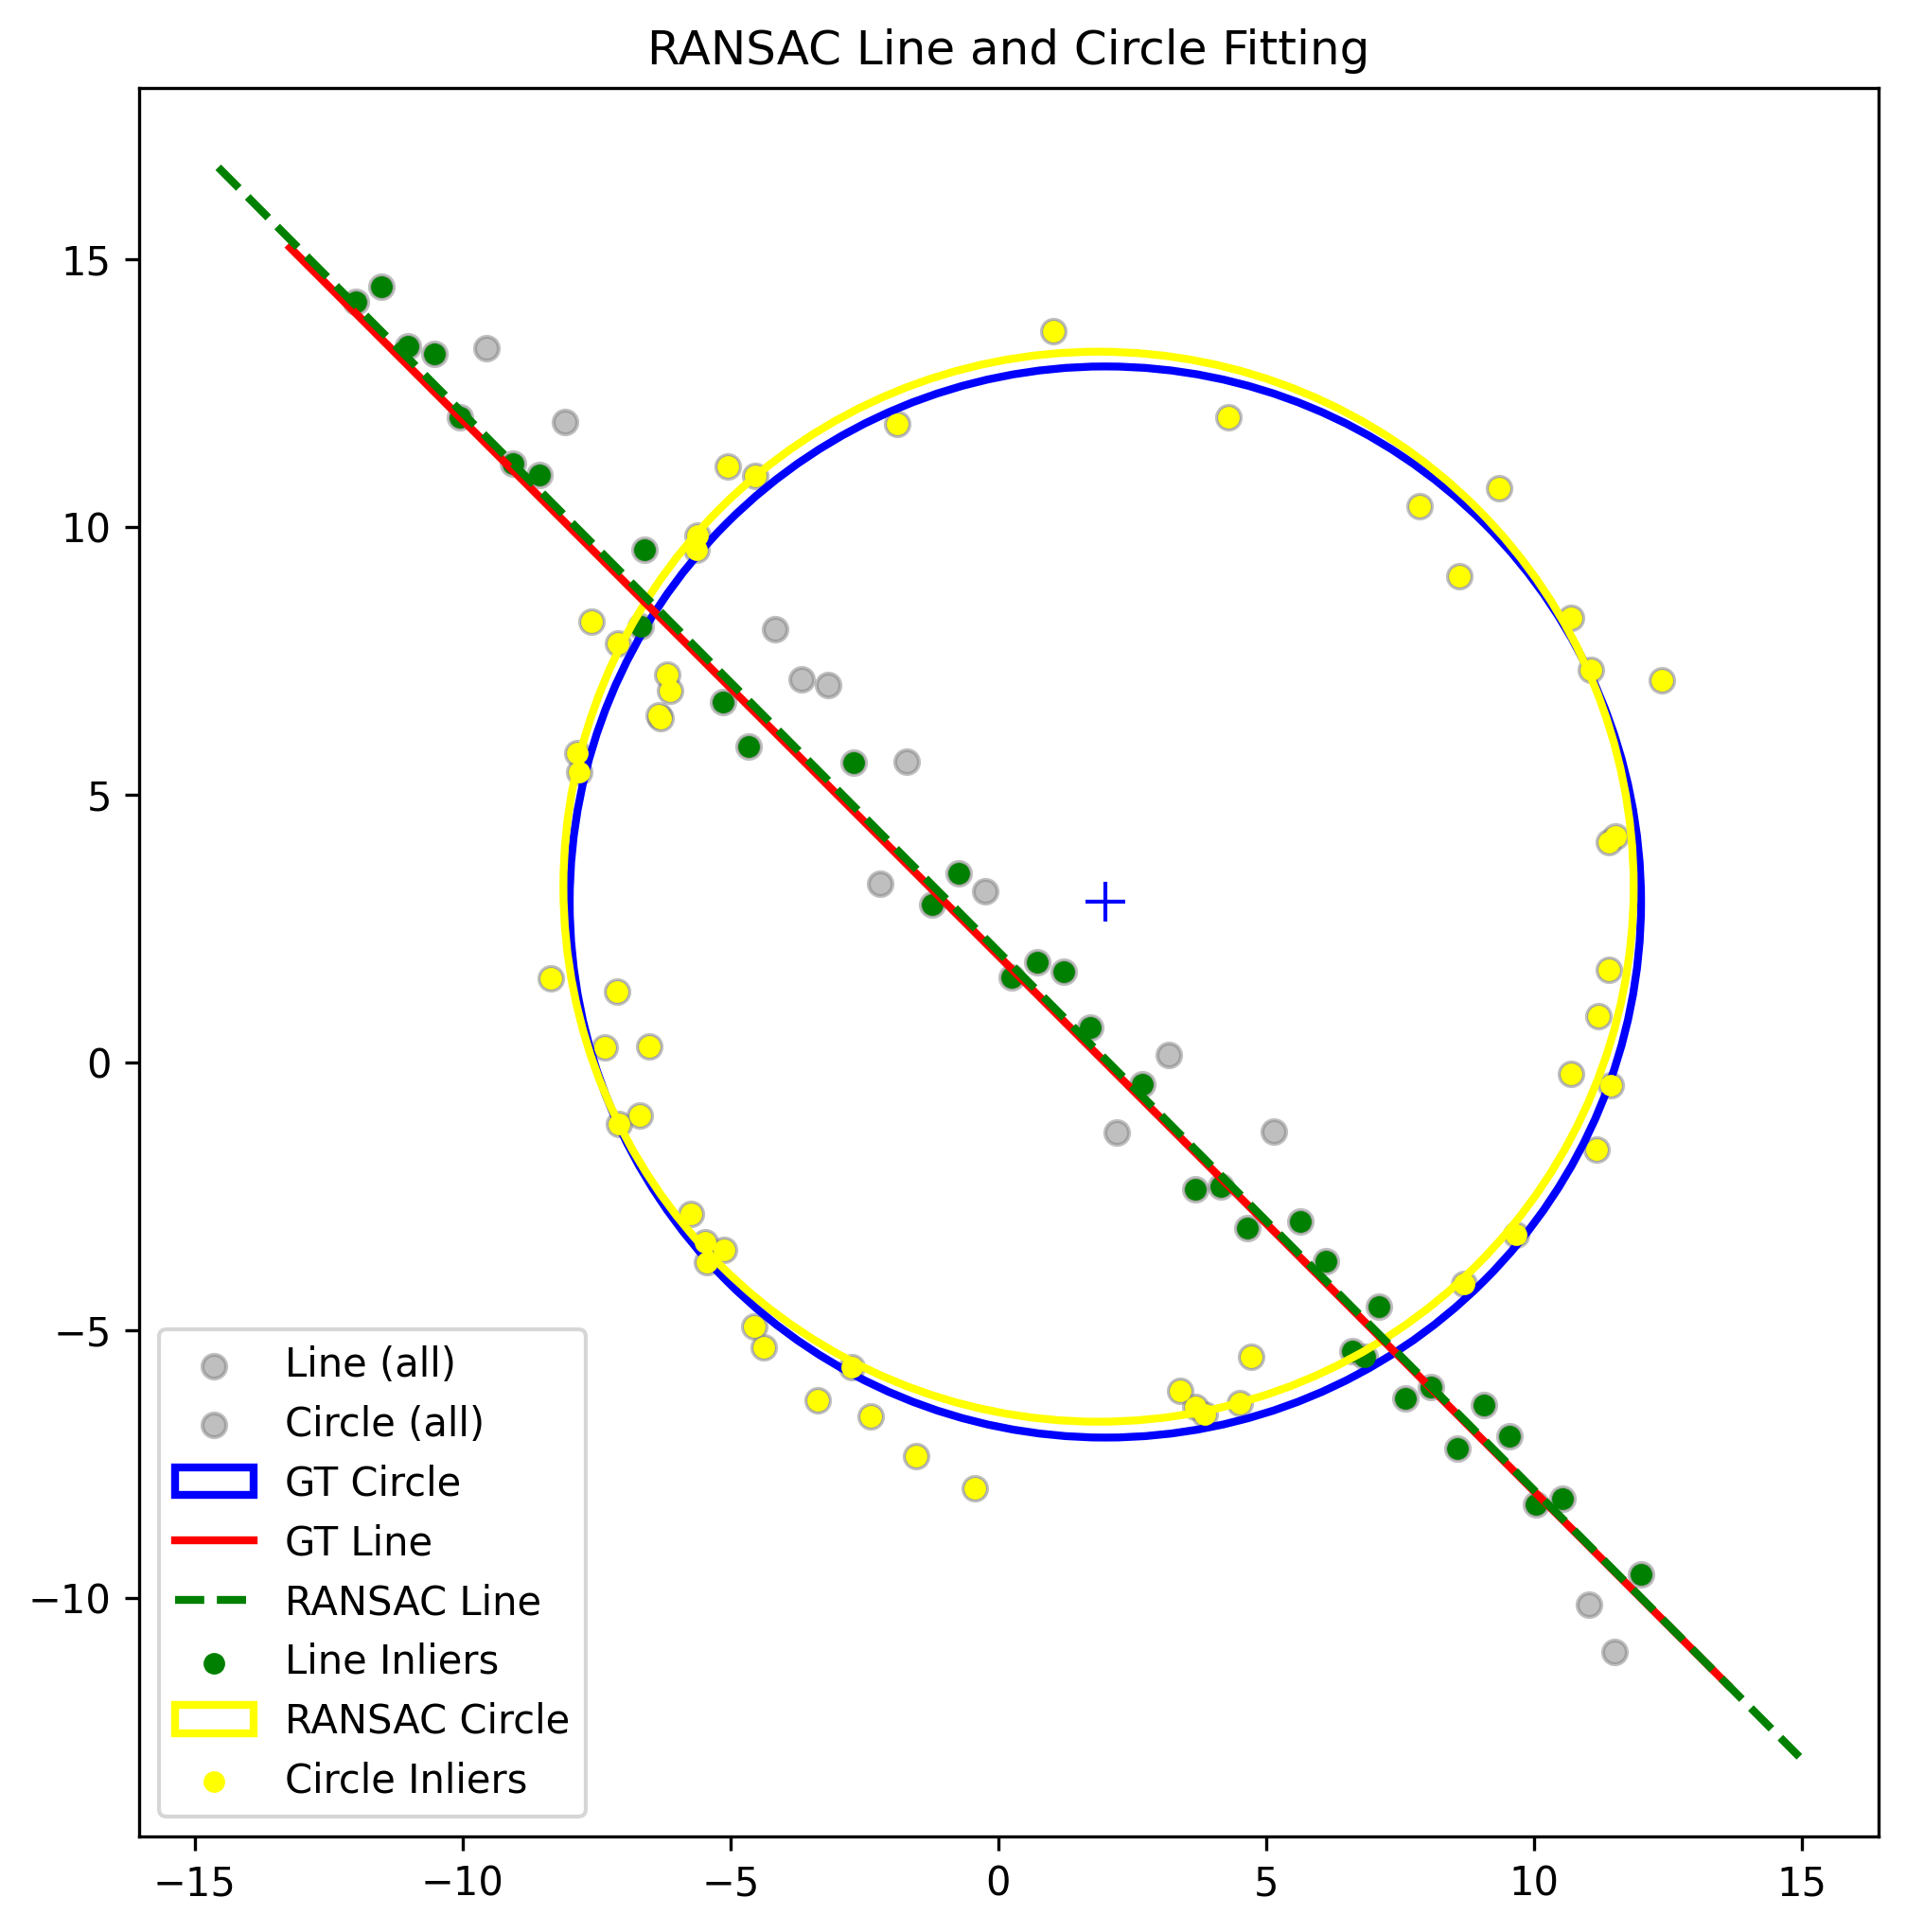

In [95]:
# Fit line first
line_params, line_inliers = ransac_line(X)

# Remove line inliers to fit circle
line_inliers_set = set(map(tuple, line_inliers))
remaining = np.array([pt for pt in X if tuple(pt) not in line_inliers_set])

# Fit circle on remaining points
circle_params, circle_inliers = ransac_circle(remaining)

# Save results
np.savez(RESULTS / "ransac_results.npz",
         line_params=line_params,
         line_inliers=line_inliers,
         circle_params=circle_params,
         circle_inliers=circle_inliers,
         remaining_points=remaining)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)

# Original data
ax.scatter(X_line[:, 0], X_line[:, 1], c='gray', alpha=0.5, label='Line (all)')
ax.scatter(X_circ[:, 0], X_circ[:, 1], c='gray',
           alpha=0.5, label='Circle (all)')

# Ground truth
gt_circle = plt.Circle((x0_gt, y0_gt), r_gt, color='blue',
                       fill=False, lw=2, label='GT Circle')
ax.add_patch(gt_circle)
ax.plot(x0_gt, y0_gt, '+', color='blue', markersize=10)
x_vals_gt = np.array(ax.get_xlim())
y_vals_gt = m_gt * x_vals_gt + b_gt
ax.plot(x_vals_gt, y_vals_gt, color='red', lw=2, label='GT Line')

# Estimated models
if line_params is not None:
    a, b, d = line_params
    x_vals = np.array(ax.get_xlim())
    y_vals = -(a * x_vals + d) / b
    ax.plot(x_vals, y_vals, 'g--', lw=2, label='RANSAC Line')
    ax.scatter(line_inliers[:, 0], line_inliers[:, 1],
               c='green', s=20, label='Line Inliers')

if circle_params is not None:
    x0, y0, r = circle_params
    est_circle = plt.Circle((x0, y0), r, color='yellow',
                            fill=False, lw=2, label='RANSAC Circle')
    ax.add_patch(est_circle)
    ax.scatter(circle_inliers[:, 0], circle_inliers[:, 1],
               c='yellow', s=20, label='Circle Inliers')

ax.set_aspect('equal', adjustable='box')
ax.legend()
ax.set_title("RANSAC Line and Circle Fitting")
plt.savefig(RESULTS / "q2_fit_result.png", bbox_inches='tight', dpi=300)
plt.show()

In [96]:
print("=== LINE FITTING RESULTS ===")
if line_params is not None:
    print(f"Number of line inliers: {len(line_inliers)}")
    print(f"Estimated line parameters:")
    print(f"  a (normal x): {line_params[0]:.4f}")
    print(f"  b (normal y): {line_params[1]:.4f}")
    print(f"  d (distance): {line_params[2]:.4f}")
    # Verify unit norm
    norm = np.sqrt(line_params[0]**2 + line_params[1]**2)
    print(f"  ||[a,b]|| = {norm:.6f} (should be 1.0)")
else:
    print("Line fitting failed.")

=== LINE FITTING RESULTS ===
Number of line inliers: 35
Estimated line parameters:
  a (normal x): 0.7091
  b (normal y): 0.7051
  d (distance): -1.4644
  ||[a,b]|| = 1.000000 (should be 1.0)


In [97]:
print("\n=== CIRCLE FITTING RESULTS ===")
if circle_params is not None:
    print(f"Number of circle inliers: {len(circle_inliers)}")
    print(f"Estimated circle parameters:")
    print(f"  Center x: {circle_params[0]:.4f}")
    print(f"  Center y: {circle_params[1]:.4f}")
    print(f"  Radius:   {circle_params[2]:.4f}")
else:
    print("Circle fitting failed.")


=== CIRCLE FITTING RESULTS ===
Number of circle inliers: 52
Estimated circle parameters:
  Center x: 1.8726
  Center y: 3.2857
  Radius:   9.9898
